#### `This dataset is obtained from the Supplementary Material of the article Orbital-engineered anomalous Hall conductivity in stable full Heusler compounds: a pathway to optimized spintronics by Viet Q. Bui et al.`
https://doi.org/10.1039/d4tc02116a

In [1]:
##Import the modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_squared_error

In [2]:
Descriptor = pd.read_csv("Elemental_Descriptor_Big_Validation_Data.csv")
Descriptor.rename(columns={'a(Å)': 'LatticeConstant'}, inplace=True)
Descriptor.head(2)

,ID,Compound,X,Y,Z,Structure,LatticeConstant,X2YZ,Element,Atomic-volume_1,Allen-EN_1,Atomic-volume_2,Allen-EN_2,Atomic-volume_3,Allen-EN_3
0,1687,Rh2MnGa,Rh,Mn,Ga,l21,6.040,True,Rh Mn Ga,8.298831,9.259,7.525759,10.34,11.797462,10.390
1,1738,Rh2PtAl,Rh,Pt,Al,l21,6.154,True,Rh Pt Al,8.298831,9.259,9.073674,10.16,9.993162,9.539


In [3]:
Descriptor.shape

(2587, 15)

In [4]:
Descriptor1 = Descriptor[['Compound', 'LatticeConstant','Atomic-volume_1','Atomic-volume_2','Atomic-volume_3','Allen-EN_1','Allen-EN_2', 'Allen-EN_3']]
Descriptor1['Atomic_Volume_Avg'] = (2*Descriptor1['Atomic-volume_1']+Descriptor1['Atomic-volume_2']+Descriptor1['Atomic-volume_3'])/4
Descriptor1['Allen_Avg'] = (2*Descriptor1['Allen-EN_1']+Descriptor1['Allen-EN_2']+Descriptor1['Allen-EN_3'])/4
Descriptor1.head(2)

,Compound,LatticeConstant,Atomic-volume_1,Atomic-volume_2,Atomic-volume_3,Allen-EN_1,Allen-EN_2,Allen-EN_3,Atomic_Volume_Avg,Allen_Avg
0,Rh2MnGa,6.040,8.298831,7.525759,11.797462,9.259,10.34,10.390,8.980221,9.81200
1,Rh2PtAl,6.154,8.298831,9.073674,9.993162,9.259,10.16,9.539,8.916125,9.55425


In [5]:
ML_Model_Compound_List = ['Zr2NiGa', 'Co2ScGa', 'Co2ScSn', 'Co2TiSi', 'Co2TiGe', 'Co2HfSn', 'Co2NbAl', 'Co2YP', 'Co2YAs', 'Co2YSb', 'Co2YBi', 'Cr2CoSb', 'Cr2FeSb', 'Cr2NiSb', 'Co2RuGa', 'Fe2RuGa', 'Mn2RuGa', 'Cr2RuGa', 'V2RuGa', 'Ti2RuGa', 'Mn2CrAl', 'Mn2CrGa', 'Mn2CrSi', 'Mn2CrGe', 'Mn2CrSb', 'Mn2FeAl', 'Mn2FeGa', 'Mn2FeSi', 'Mn2FeGe', 'Mn2FeSb', 'Cr2CoAl', 'Cr2CoGa', 'Cr2CoIn', 'Cr2CoSi', 'Cr2CoGe', 'Cr2CoSn', 'Cr2CoSb', 'Cr2NiAl', 'Cr2NiGa', 'Cr2NiIn', 'Cr2NiSi', 'Cr2NiGe', 'Cr2NiSn', 'Cr2NiSb', 'Fe2MoGe', 'Fe2MoSb', 'Co2MoGe', 'Co2MoSb', 'Mn2PdV', 'Mn2NiV', 'Mn2AgV', 'Mn2AuV', 'Mn2CoV', 'Mn2PtV', 'Mn2IrV', 'V2CrSb', 'V2MnSb', 'V2FeSb', 'V2CoSb', 'Sc2VIn', 'Sc2VSi', 'Sc2VGe', 'Sc2VSn', 'Sc2CrAl', 'Sc2CrGa', 'Sc2CrIn', 'Sc2CrSi', 'Sc2CrGe', 'Sc2CrSn', 'Sc2MnSi', 'Sc2MnGe', 'Sc2MnSn', 'Ti2VSi', 'Ti2VGe', 'Ti2VSn', 'Sc2CoSi', 'Sc2CoGe', 'Sc2CoSn', 'Ti2MnSi', 'Ti2MnGe', 'Ti2MnSn', 'Ti2FeAl', 'Ti2FeGa', 'Ti2FeIn', 'Ti2FeSi', 'Ti2FeGe', 'Ti2FeSn', 'Ti2CoAl', 'Ti2CoGa', 'Ti2CoIn', 'V2CrGe', 'V2MnAl', 'V2MnGa', 'Ti2CoSi', 'Ti2CoGe', 'Ti2CoSn', 'Ti2NiAl', 'Ti2NiGa', 'Ti2NiIn', 'Cr2MnAl', 'Cr2NiAl', 'Cr2CoP', 'Mn2FeP', 'Mn2FeAs', 'Mn2CoP', 'Mn2CoAs', 'Mn2CuSi', 'Sc2VAl', 'Sc2VGa', 'Sc2MnAl', 'Sc2MnGa', 'Sc2MnIn', 'Sc2VSb', 'Ti2VAl', 'Ti2VGa', 'Sc2CrP', 'Sc2CrSb', 'Sc2FeAl', 'Sc2FeGa', 'Sc2FeIn', 'Ti2CrAl', 'Ti2CrGa', 'Ti2CrIn', 'Sc2MnSb', 'Ti2VP', 'Sc2NiAl', 'Sc2NiGa', 'Sc2NiIn', 'Ti2CrSb', 'Sc2CoSb', 'Ti2CrAs', 'Sc2NiSi', 'Sc2NiGe', 'Sc2NiSn', 'Ti2MnSb', 'Ti2FeAs', 'V2FeGa', 'Ti2NiSn', 'Ti2FeSb', 'V2FeAl', 'V2MnGe', 'V2MnSn', 'V2FeGe', 'Cr2MnGa', 'Cr2MnGe', 'V2CoSi', 'Cr2CoAl', 'Cr2CoSi', 'Cr2CoGe', 'Mn2FeAl', 'Mn2FeGa', 'Cr2NiSi', 'Cr2NiGe', 'Mn2FeSi', 'Mn2FeGe', 'Mn2CuP', 'Mn2RhAl', 'Mn2RhGa', 'Mn2RhIn', 'Mn2RhSi', 'Mn2RhGe', 'Hf2CoGa', 'Hf2CoIn', 'Mn2NiGa', 'Mn2NiIn', 'Mn2NiSn', 'Mn2NiSb', 'Mn2RuSi', 'Mn2RuGe', 'Mn2CoAl', 'Mn2CoGa', 'Mn2CoIn', 'Mn2CoSi', 'Mn2CoGe', 'Mn2CoSn', 'Mn2CoSb', 'Fe2NiAl', 'Fe2NiGa', 'Fe2NiSi', 'Fe2NiGe', 'Zr2RhAl', 'Zr2RhGa', 'Zr2RhIn', 'Cr2PtGa', 'Mn2PtGa', 'Fe2PtGa', 'Co2PtGa', 'Co2MnAl', 'Co2MnGe', 'Co2MnSi', 'Co2MnGa', 'Sc2CoAl', 'Sc2CoGa', 'Sc2CoIn', 'Co2TiPb', 'Co2MoPb', 'V2TiGa', 'V2TiGe', 'V2CrGa', 'V2TiAs', 'V2MnGa', 'V2CrGe', 'V2FeGa', 'V2MnGe', 'V2CrAs', 'V2CoGa', 'V2FeGe', 'V2MnAs', 'V2NiGa', 'V2CoGe', 'V2FeAs', 'Fe2CoGa', 'Fe2CoSi', 'Fe2CoGe', 'Fe2CuAl', 'Fe2CuGa', 'Cr2ZnSi', 'Cr2ZnGe', 'Fe2NiMn', 'Fe2NiCo', 'Fe2CoAl', 'Fe2CoIn', 'Fe2CoSn', 'Ni2NbAl', 'Ni2NbGa', 'Ni2NbSn', 'Ni2MnAl', 'Ni2MnGa', 'Ni2MnIn', 'Ni2MnSi', 'Ni2MnGe', 'Ni2MnSn', 'Ni2MnPb', 'Ni2MnP', 'Ni2MnAs', 'Ni2MnSb', 'Ni2MnBi', 'Ni2CrAl', 'Ni2CrGa', 'Ni2CrIn', 'Ni2CrSi', 'Ni2CrGe', 'Ni2CrSn', 'Ni2CrPb', 'Ni2CrP', 'Ni2CrAs', 'Ni2CrSb', 'Ni2CrBi', 'Co2YGe', 'Ti2CoPb', 'Ti2FePb', 'Sc2FeSi', 'Sc2FeGe', 'Sc2TiAl', 'Sc2TiGa', 'Sc2TiIn', 'Sc2TiSi', 'Sc2TiGe', 'Sc2TiSn', 'Sc2TiP', 'Sc2TiAs', 'Sc2TiSb', 'Sc2VP', 'Sc2VAs', 'Sc2CrAs', 'Sc2CrSn', 'Sc2CrP', 'Sc2MnAs', 'Sc2MnSn', 'Sc2MnP', 'Sc2MnSb', 'Sc2FeSn', 'Sc2FeP', 'Sc2FeAs', 'Sc2FeSb', 'Sc2CoP', 'Sc2CoAs', 'Sc2CoSb', 'Sc2NiP', 'Sc2NiAs', 'Sc2NiSb', 'Sc2CuAl', 'Sc2CuGa', 'Sc2CuIn', 'Sc2CuSi', 'Sc2CuGe', 'Sc2CuSn', 'Sc2CuAs', 'Sc2CuSb', 'Sc2CuP', 'Sc2ZnAl', 'Sc2ZnGa', 'Sc2ZnIn', 'Sc2ZnSi', 'Sc2ZnGe', 'Sc2ZnSn', 'Sc2ZnP', 'Sc2ZnAs', 'Sc2ZnSb', 'Sc2YAl', 'Sc2YGa', 'Sc2YIn', 'Sc2YSi', 'Sc2YGe', 'Sc2YSn', 'Sc2YP', 'Sc2YAs', 'Sc2YSb', 'Sc2ZrAl', 'Sc2ZrGa', 'Sc2ZrIn', 'Sc2ZrSi', 'Sc2ZrGe', 'Sc2ZrSn', 'Sc2ZrP', 'Sc2ZrAs', 'Sc2ZrSb', 'Sc2NbAl', 'Sc2NbGa', 'Sc2NbIn', 'Sc2NbSi', 'Sc2NbGe', 'Sc2NbSn', 'Sc2NbP', 'Sc2NbAs', 'Sc2NbSb', 'Sc2MoAl', 'Sc2MoGa', 'Sc2MoIn', 'Sc2MoSi', 'Sc2MoGe', 'Sc2MoSn', 'Sc2MoP', 'Sc2MoAs', 'Sc2MoSb', 'Sc2TcAl', 'Sc2TcGa', 'Sc2TcIn', 'Sc2TcSi', 'Sc2TcGe', 'Sc2TcSn', 'Sc2TcP', 'Sc2TcAs', 'Sc2TcSb', 'Sc2RuAl', 'Sc2RuGa', 'Sc2RuIn', 'Sc2RuSi', 'Sc2RuGe', 'Sc2RuSn', 'Sc2RuP', 'Sc2RuAs', 'Sc2RuSb', 'Sc2RhAl', 'Sc2RhGa', 'Sc2RhIn', 'Sc2RhSi', 'Sc2RhGe', 'Sc2RhSn', 'Sc2RhP', 'Sc2RhAs', 'Sc2RhSb', 'Sc2PdAl', 'Sc2PdGa', 'Sc2PdIn', 'Sc2PdSi', 'Sc2PdGe', 'Sc2PdSn', 'Sc2PdP', 'Sc2PdAs', 'Sc2PdSb', 'Sc2AgAl', 'Sc2AgGa', 'Sc2AgIn', 'Sc2AgSi', 'Sc2AgGe', 'Sc2AgSn', 'Sc2AgP', 'Sc2AgAs', 'Sc2AgSb', 'Sc2CdAl', 'Sc2CdGa', 'Sc2CdIn', 'Sc2CdSi', 'Sc2CdGe', 'Sc2CdSn', 'Sc2CdP', 'Sc2CdAs', 'Sc2CdSb']
Valdiation_Compound_List = list(Descriptor['Compound'])

In [6]:
overlap = sorted(set(ML_Model_Compound_List) & set(Valdiation_Compound_List))

print("Number of overlapping compounds:", len(overlap))
print("Overlapping compounds:")
print(overlap)

Number of overlapping compounds: 0
Overlapping compounds:
[]


In [7]:
len(ML_Model_Compound_List )

389

### `SISSO+LASSO Model Dataframe`

In [8]:
dataset1 = Descriptor1.copy()

In [9]:
# SISSO 1D descriptor
dataset1['d1'] = (
    (dataset1['Atomic_Volume_Avg'] / np.cbrt(dataset1['Allen_Avg']))
    / dataset1['Allen_Avg']
)
dataset1.head(2)

,Compound,LatticeConstant,Atomic-volume_1,Atomic-volume_2,Atomic-volume_3,Allen-EN_1,Allen-EN_2,Allen-EN_3,Atomic_Volume_Avg,Allen_Avg,d1
0,Rh2MnGa,6.040,8.298831,7.525759,11.797462,9.259,10.34,10.390,8.980221,9.81200,0.427507
1,Rh2PtAl,6.154,8.298831,9.073674,9.993162,9.259,10.16,9.539,8.916125,9.55425,0.439792


In [10]:
dataset1['Lattice_Constant_Fromula'] =  2.18*dataset1['d1']+5.04
dataset1= dataset1.round(decimals = 2)
dataset1['Diff_SISSO']  = abs(dataset1['Lattice_Constant_Fromula']- dataset1['LatticeConstant'])
#dataset1['d1'] = dataset.drop('d1', axis=1)
dataset2= dataset1[['Compound','LatticeConstant','Lattice_Constant_Fromula','Diff_SISSO']]
dataset2.head(2)

,Compound,LatticeConstant,Lattice_Constant_Fromula,Diff_SISSO
0,Rh2MnGa,6.04,5.97,0.07
1,Rh2PtAl,6.15,6.00,0.15


In [11]:
dataset2['Diff_SISSO'].describe(
    percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95]
)


count    2587.000000
mean        0.145319
std         0.108222
min         0.000000
10%         0.030000
20%         0.050000
30%         0.070000
40%         0.100000
50%         0.130000
60%         0.150000
70%         0.190000
80%         0.230000
90%         0.290000
95%         0.340000
max         0.690000
Name: Diff_SISSO, dtype: float64

In [12]:
# count    2587.000000
# mean        0.145319
# std         0.108222
# min         0.000000
# 10%         0.030000
# 20%         0.050000
# 30%         0.070000
# 40%         0.100000
# 50%         0.130000
# 60%         0.150000
# 70%         0.190000
# 80%         0.230000
# 90%         0.290000
# 95%         0.340000
# max         0.690000
# Name: Diff_SISSO, dtype: float64

# `MAE:`

In [13]:
from sklearn.metrics import mean_absolute_error

mae_test = mean_absolute_error(
    dataset2['LatticeConstant'],
    dataset2['Lattice_Constant_Fromula']
)

print(f"MAE = {mae_test:.3f} Å")

MAE = 0.145 Å


In [14]:
# MAE = 0.145 Å

In [15]:
y = dataset2['LatticeConstant']
yhat = dataset2['Lattice_Constant_Fromula']

print("Target range:", y.min(), y.max())
print("Target std:", y.std())
print("Prediction range:", yhat.min(), yhat.max())
print("Prediction std:", yhat.std())

print("MAE:", mean_absolute_error(y, yhat))
print("RMSE:", np.sqrt(mean_squared_error(y, yhat)))
print("R2:", r2_score(y, yhat))


Target range: 5.31 7.46
Target std: 0.32656546545861675
Prediction range: 5.56 7.41
Prediction std: 0.25351757090284877
MAE: 0.1453189022033243
RMSE: 0.18117684266626255
R2: 0.6920836355068762


In [16]:
# Target range: 5.31 7.46
# Target std: 0.32656546545861675
# Prediction range: 5.56 7.41
# Prediction std: 0.25351757090284877
# MAE: 0.1453189022033243
# RMSE: 0.18117684266626255
# R2: 0.6920836355068762

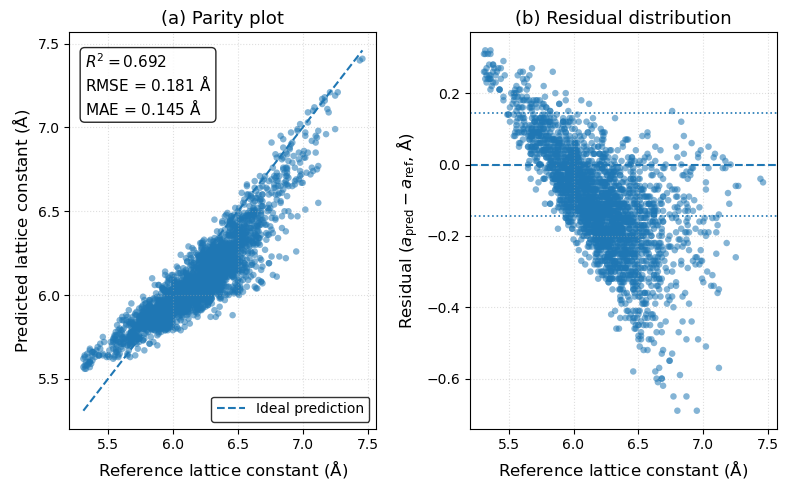

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# Data
# ============================================================
y_true = dataset2['LatticeConstant'].to_numpy()
y_pred = dataset2['Lattice_Constant_Fromula'].to_numpy()

# ============================================================
# Metrics
# ============================================================
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

residual = y_pred - y_true
abs_error = np.abs(residual)

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(
    1, 2,
    figsize=(8, 5)
)

# ------------------------------------------------------------
# (a) Parity plot
# ------------------------------------------------------------
ax[0].scatter(
    y_true,
    y_pred,
    s=22,
    alpha=0.55,
    edgecolor='none'
)

# Perfect prediction line
xmin = min(y_true.min(), y_pred.min())
xmax = max(y_true.max(), y_pred.max())

ax[0].plot(
    [xmin, xmax],
    [xmin, xmax],
    '--',
    linewidth=1.5,
    label='Ideal prediction'
)

ax[0].set_xlabel(r'Reference lattice constant ($\mathrm{\AA}$)', fontsize=12)
ax[0].set_ylabel(r'Predicted lattice constant ($\mathrm{\AA}$)', fontsize=12)

ax[0].set_title('(a) Parity plot', fontsize=13)

# Metrics
textstr = (
    rf'$R^2 = {r2:.3f}$' '\n'
    rf'RMSE = {rmse:.3f} $\mathrm{{\AA}}$' '\n'
    rf'MAE = {mae:.3f} $\mathrm{{\AA}}$'
)

ax[0].text(
    0.05,
    0.95,
    textstr,
    transform=ax[0].transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        alpha=0.85
    )
)

ax[0].legend(
    frameon=True,
    edgecolor='black',
    loc='lower right'
)

ax[0].grid(
    True,
    linestyle=':',
    alpha=0.4
)

# ------------------------------------------------------------
# (b) Residual plot
# ------------------------------------------------------------
ax[1].scatter(
    y_true,
    residual,
    s=22,
    alpha=0.55,
    edgecolor='none'
)

ax[1].axhline(
    0,
    linestyle='--',
    linewidth=1.5
)

# ± MAE reference
ax[1].axhline(
    mae,
    linestyle=':',
    linewidth=1.2
)

ax[1].axhline(
    -mae,
    linestyle=':',
    linewidth=1.2
)

ax[1].set_xlabel(
    r'Reference lattice constant ($\mathrm{\AA}$)',
    fontsize=12
)

ax[1].set_ylabel(
    r'Residual ($a_{\mathrm{pred}}-a_{\mathrm{ref}}$, $\mathrm{\AA}$)',
    fontsize=12
)

ax[1].set_title('(b) Residual distribution', fontsize=13)

ax[1].grid(
    True,
    linestyle=':',
    alpha=0.4
)

plt.tight_layout()
plt.show()

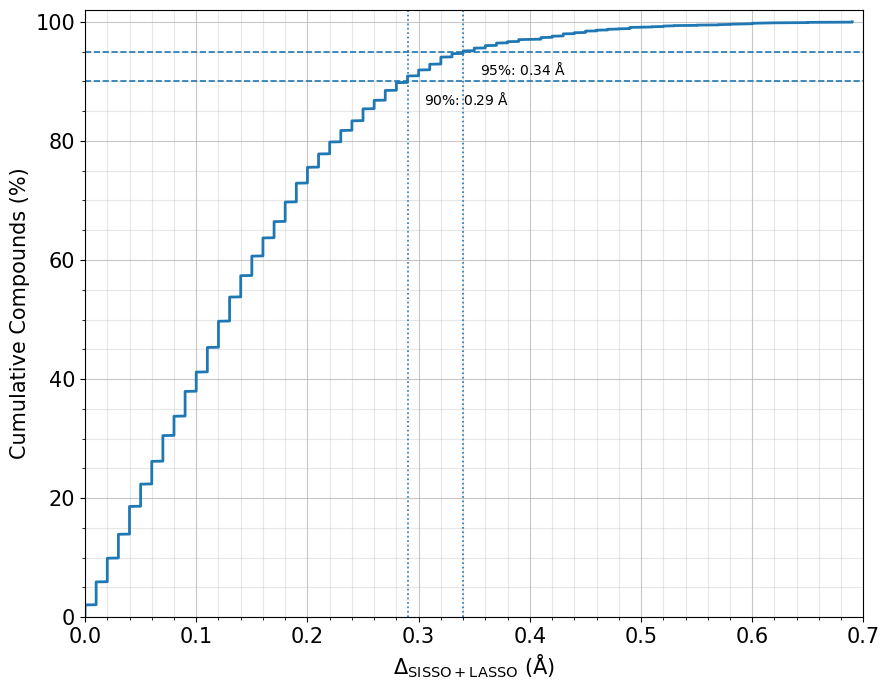

50th percentile = 0.130 Å
80th percentile = 0.230 Å
90th percentile = 0.290 Å
95th percentile = 0.340 Å


In [18]:
# ============================================================
# Cumulative absolute error distribution
# ============================================================

abs_error = np.abs(y_pred - y_true)

sorted_error = np.sort(abs_error)

cumulative_fraction = (
    np.arange(1, len(sorted_error) + 1)
    / len(sorted_error)
    * 100
)

# Percentile values
p50 = np.percentile(abs_error, 50)
p80 = np.percentile(abs_error, 80)
p90 = np.percentile(abs_error, 90)
p95 = np.percentile(abs_error, 95)

plt.figure(figsize=(9, 7))

plt.plot(
    sorted_error,
    cumulative_fraction,
    linewidth=2
)

# Important percentile lines
plt.axhline(
    90,
    linestyle='--',
    linewidth=1.2
)

plt.axhline(
    95,
    linestyle='--',
    linewidth=1.2
)

plt.axvline(
    p90,
    linestyle=':',
    linewidth=1.2
)

plt.axvline(
    p95,
    linestyle=':',
    linewidth=1.2
)

# Labels
plt.text(
    p90 + 0.015,
    86,
    rf'90%: {p90:.2f} $\mathrm{{\AA}}$',
    fontsize=10
)

plt.text(
    p95 + 0.015,
    91,
    rf'95%: {p95:.2f} $\mathrm{{\AA}}$',
    fontsize=10
)

plt.xlabel(
    r'$\Delta_{\mathrm{SISSO+LASSO}}$ ($\mathrm{\AA}$)',
    fontsize=15
)

plt.ylabel(
    'Cumulative Compounds (%)',
    fontsize=15
)

# plt.title(
#     'Cumulative distribution of absolute prediction error',
#     fontsize=13
# )

plt.xlim(0, max(0.7, p95 + 0.1))
plt.ylim(0, 102)

# plt.grid(
#     True,
#     linestyle=':',
#     alpha=0.4
# )
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.minorticks_on()
plt.grid(True, which='major', alpha=0.7)
plt.grid(True, which='minor', alpha=0.3)
plt.tight_layout()
#plt.savefig('Delta_SISSO_LASSO.pdf')
plt.show()

print(f"50th percentile = {p50:.3f} Å")
print(f"80th percentile = {p80:.3f} Å")
print(f"90th percentile = {p90:.3f} Å")
print(f"95th percentile = {p95:.3f} Å")

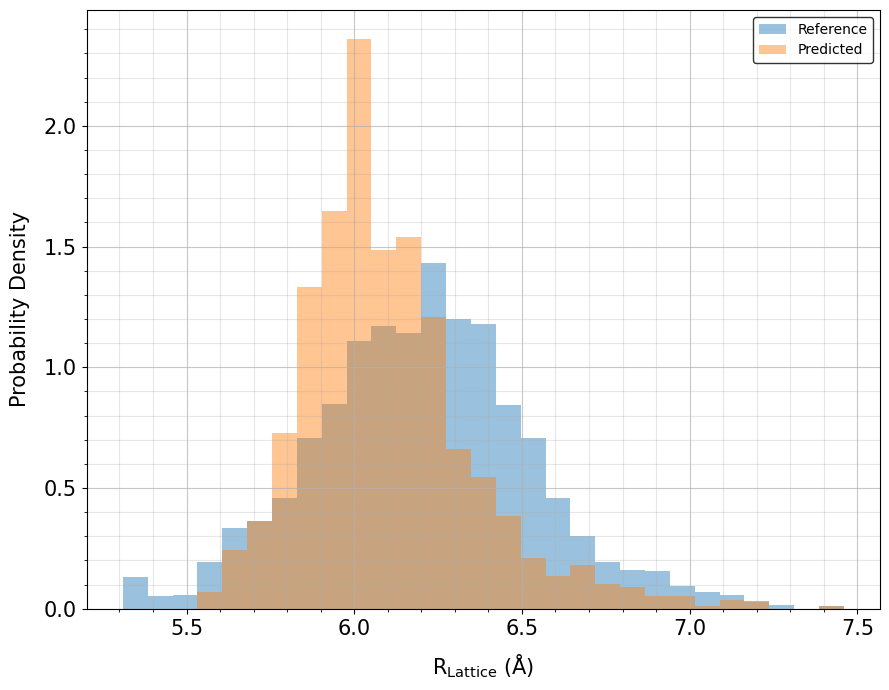

In [19]:
# ============================================================
# Distribution comparison
# ============================================================

plt.figure(figsize=(9, 7))

bins = np.linspace(
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max()),
    30
)

plt.hist(
    y_true,
    bins=bins,
    density=True,
    alpha=0.45,
    label='Reference'
)

plt.hist(
    y_pred,
    bins=bins,
    density=True,
    alpha=0.45,
    label='Predicted'
)

plt.xlabel(
    r'R$_{\mathrm{Lattice}}$ ($\mathrm{\AA}$)',
    fontsize=15,labelpad=10
)

plt.ylabel(
    'Probability Density',
    fontsize=15,labelpad=10
)

# plt.title(
#     'Reference and predicted lattice-constant distributions',
#     fontsize=13
# )

plt.legend(
    frameon=True,
    edgecolor='black'
)

# plt.grid(
#     True,
#     linestyle=':',
#     alpha=0.4
# )
# Customize tick size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.minorticks_on()
plt.grid(True, which='major', alpha=0.7)
plt.grid(True, which='minor', alpha=0.3)
plt.tight_layout()
#plt.savefig('Dist_SISSO_LASSO.pdf')
plt.show()